In [7]:
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt
from torchvision.transforms import transforms

In [2]:
TrainData = CIFAR10(root='../data', train=True, download=True)

In [3]:
TrainData[1]

(<PIL.Image.Image image mode=RGB size=32x32>, 9)

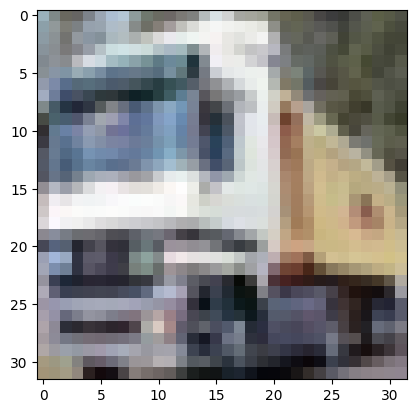

In [4]:
plt.imshow(TrainData[1][0])

In [5]:
TrainData = CIFAR10(root='../data', train=True, download=True, transform= transforms.Compose([transforms.ToTensor()]))

In [8]:
TrainLoader = DataLoader(dataset=TrainData, batch_size=64, shuffle=True)

In [26]:
def mean_std_ImageDataset(dataloader,num_chanels):
    r'''
    - Chuẩn hóa theo std và mean của từng batch size do giới hạn phần cứng
    - Trọng số mean, std cuối cùng được tính bằng giá trị trung bình có trọng số của các giá trị mean, std trong các batch
    - Khi bacth_size đủ lớn thì std ~ gần đúng lý thuyết
    '''
    mean = torch.zeros(num_chanels)
    std = torch.zeros(num_chanels)
    total_batch_size = 0
    for img,label in dataloader:
        # image có shape(batch_size,C,H,W)
        batch_size = img.shape[0]
        img = img.view(batch_size,num_chanels,-1) #(B,C,H*W)

        # Tính giá trung bình có trọng số do batch cuối thường nhỏ hơn mức batch_size quy định 
        mean += torch.mean(img,dim = [0,2])*batch_size
        std +=torch.std(img,dim=[0,2])*batch_size
        total_batch_size += batch_size
    mean/= total_batch_size
    std/=total_batch_size
    return mean, std
mean, std = mean_std_ImageDataset(TrainLoader,3)

In [25]:
print(mean)
print(std)

tensor([0.4914, 0.4822, 0.4465])
tensor([0.2464, 0.2428, 0.2606])
